# Tuning the ensemble

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/tuning.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/tuning.ipynb)

Every model in `lazy` runs as an ensemble, and a few shared parameters set
how many members it has, what each member sees and how sharp the combined
distribution is. Since the defaults are already good, we do not argue here
that they need tuning. Instead, we change one setting at a time on a single
dataset and measure its effect on the accuracy, calibration and cost of the
predicted distributions.

## Setup

On Google Colab, the cell below installs the package with the TabPFN and
TabFM backends. Elsewhere, install it first with
`pip install 'lazy-tfm[tabpfn,tabfm]'`. TabFM is used only in the last
section, which is skipped when it is not installed.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn,tabfm]'
    pass

In [2]:
import importlib.util  # To check for the optional TabFM backend
import time  # Wall-clock timing

import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables

import lazy
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 0  # One seed for the split and for every ensemble

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

We use `kin8nm`, the simulated forward kinematics of an eight-link robot arm,
which has 8,192 rows and eight features (the joint angles). The target is the
distance of the end of the arm from a fixed point. We make one random split,
keeping 2,000 rows as the context and another 2,000 as the test set, so that
each of the many fits below takes seconds. The full dataset (about 6,000
context rows) would make each fit a few times slower.

In [3]:
data = datasets.load_dataset("kin8nm")
X, y = data.X, data.y

rng = np.random.default_rng(SEED)
order = rng.permutation(len(y))
context, test = order[:2_000], order[2_000:4_000]
X_context, y_context = X.iloc[context], y[context]
X_test, y_test = X.iloc[test], y[test]

print(f"{len(context):,} context rows, {len(test):,} test rows")
X.head()

2,000 context rows, 2,000 test rows


,theta1,theta2,theta3,theta4,theta5,theta6,theta7,theta8
0,-0.015119,0.360741,0.469398,1.309675,0.988024,-0.025493,0.664071,0.062763
1,0.360478,-0.301395,0.629183,-1.440146,-0.741637,-1.196749,-1.038444,-0.717461
2,1.563238,-1.294753,0.078987,1.432937,1.149136,-1.292140,1.562988,-0.937731
3,0.199485,0.901157,-1.356304,-0.080525,-0.976628,0.829894,-0.855649,0.930630
4,0.659737,0.120552,-0.008756,0.648839,0.626832,-0.646539,1.318074,-0.899172


## Measuring a setting

The function below fits one model, predicts the native distribution of
every test row and times both steps together. From the distribution, we
compute the CRPS and the NLL (the mean negative log density at the truth)
on a fine grid (lower is better for both), and the fraction of true values
inside the exact central 68% interval, which should be 68% for calibrated
distributions. It also returns the PIT values (the CDF of each prediction
at its true value), which we plot later. The metrics are described in
[From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html).

In [4]:
GRID = lazy.Grid.linear(y.min() - 0.3, y.max() + 0.3, 600)


def measure(
    label: str,
    X_query: pd.DataFrame = X_test,
    y_query: np.ndarray = y_test,
    n_context: int = len(y_context),
    repeats: int = 1,
    **params: object,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Fits a model with ``params`` and scores its predictions.

    The model is TabPFN-3.5 unless ``params`` names another ``backend``, and
    its context is the first ``n_context`` context rows. The time is the
    shortest of ``repeats`` identical runs. Returns a one-row table of scores,
    and the PIT values of the query rows.
    """
    backend = params.pop("backend", "tabpfn")
    seconds = np.inf
    for _ in range(repeats):
        start = time.perf_counter()
        model = lazy.LazyModel(
            backend, random_state=SEED, progress=False, **params
        )
        model.fit(X_context.iloc[:n_context], y_context[:n_context])
        dist = model.predict_distribution(X_query)
        seconds = min(seconds, time.perf_counter() - start)
    pdfs = dist.on_grid(GRID)
    lower, upper = dist.interval(0.68).T
    _, pit = metrics.per_object_scores(y_query, GRID, pdfs)
    row = {
        "setting": label,
        "crps": metrics.crps(y_query, GRID, pdfs),
        "nll": metrics.nll(y_query, GRID, pdfs),
        "coverage_68": np.mean((lower <= y_query) & (y_query <= upper)),
        "time [s]": seconds,
    }
    return pd.DataFrame([row]), pit


def show(rows: list[pd.DataFrame]) -> pd.DataFrame:
    """Joins the rows of ``measure`` into one rounded table."""
    return pd.concat(rows).set_index("setting").round(4)

Every model loads its checkpoint at `fit`, so each time below includes a
loading cost that does not depend on the setting. We first run one throwaway
fit to exclude the download and the first load of the weights. The GPU of
this run was shared with other jobs, so the times are only indicative, and
differences of a second or so are noise. For the comparison of ensemble
sizes, where the time is the point, we take the shortest of three runs of
each.

In [5]:
_ = measure("warm-up", n_estimators=1)

## The number of members

`n_estimators` sets exactly how many members run. Each member is a full
forward pass of the model through the context with its own view of the
features, so the cost of the ensemble itself grows in proportion to the
number of members. For TabPFN, LimiX-2 and TabFM, each member predicts a
histogram and the members are combined as an equally weighted mixture of
their histograms. For TabICL, which predicts quantiles, the quantiles of the
members are averaged instead (see
[One interface for every model](https://lazy-tfm.readthedocs.io/en/latest/guide/interface.html)).

In [6]:
members = [1, 2, 4, 8, 16]
runs = {
    n: measure(f"n_estimators={n}", n_estimators=n, repeats=3) for n in members
}
by_members = show([table for table, _ in runs.values()])
unrounded = pd.concat([table for table, _ in runs.values()])  # For the plot

# The default model (8 members) is the reference of every later comparison.
default, pit_default = runs[8]
default["setting"] = "default"
by_members

,crps,nll,coverage_68,time [s]
setting,,,,
n_estimators=1,0.0390,-1.2777,0.6610,0.2045
n_estimators=2,0.0389,-1.2841,0.6725,0.3510
n_estimators=4,0.0387,-1.2909,0.6755,0.6437
n_estimators=8,0.0387,-1.2920,0.6785,1.2332
n_estimators=16,0.0387,-1.2925,0.6790,2.3930


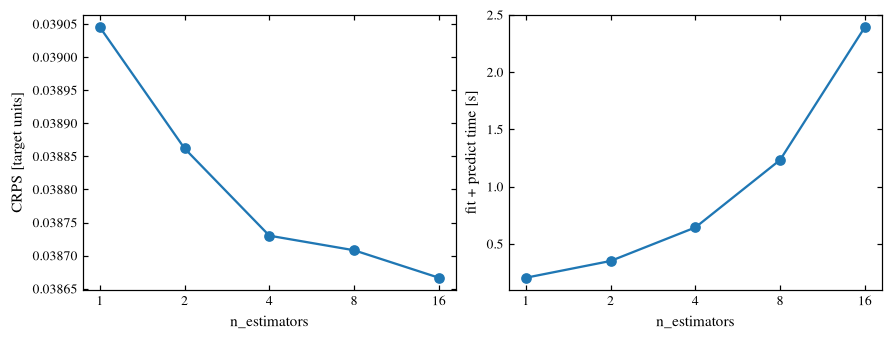

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), layout="constrained")
axes[0].plot(members, unrounded["crps"], "o-")
axes[0].set_ylabel("CRPS [target units]")
axes[1].plot(members, unrounded["time [s]"], "o-")
axes[1].set_ylabel("fit + predict time [s]")
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xticks(members, [str(n) for n in members])
    ax.set_xlabel("n_estimators")

The left panel shows the CRPS against the number of members, and the right
panel shows the time each run took. We see that, on this dataset, the CRPS
improves by less than 1% from one member to 4 and changes little after
that. The NLL and the coverage in the table also improve with the number
of members and approach their best values by 8 members, the default. The
time grows too, though more slowly than the number of members (16 members
take about 3.4 times as long as one), since at this small size the fixed
costs of a fit, such as loading the checkpoint, take a large share of it.

## Feature transforms

`transforms` names what each member does to the features before the model
sees them, and the members take the names in round-robin order. The default,
`"auto"`, is the tuned recipe of the model, which for TabPFN-3.5 includes its
fingerprint feature, its target transforms and a 12-sigma outlier clip. An
explicit recipe is all the members see. With `("none", "quantile")`, half of
the members see the raw features and half see them mapped to a normal
distribution. An explicit recipe also turns off the extras of `"auto"`, the
outlier clip included, since `outlier_threshold="auto"` then means no clip.
The guide lists every
[transform](https://lazy-tfm.readthedocs.io/en/latest/guide/interface.html#transforms).

In [8]:
recipes = [("none",), ("quantile",), ("none", "quantile"), ("power",)]
by_transforms = show(
    [default] + [measure(f"transforms={r}", transforms=r)[0] for r in recipes]
)
by_transforms

,crps,nll,coverage_68,time [s]
setting,,,,
default,0.0387,-1.2920,0.6785,1.2332
"transforms=('none',)",0.0385,-1.2940,0.6735,1.1585
"transforms=('quantile',)",0.0404,-1.2503,0.6875,1.9413
"transforms=('none', 'quantile')",0.0391,-1.2808,0.6845,2.0229
"transforms=('power',)",0.0385,-1.2942,0.6720,1.1780


The table shows that `("none",)` and `("power",)` score as well as the
default in CRPS and NLL, or marginally better, on this dataset, though
their coverage is slightly lower (0.6735 and 0.6720 vs. 0.6785). Every
recipe with the quantile transform scores worse in both CRPS and NLL.
Since the joint angles of `kin8nm` are spread evenly over their range, a
power transform has little to straighten out, and mapping them to a normal
distribution may discard some of the information in their spacing. The
power and mixed recipes also take somewhat longer, by less than the noise
of these times. TabPFN runs only `none` natively, so `lazy` applies the
other transforms itself, and the mixed recipe needs two calls of the
model, one for each transform.

## Feature shuffling

With `feature_shuffle=True` (the default), each member sees the feature
columns in a different order. Since the answer of a model depends slightly on
the column order, shuffling adds diversity among the members at no extra
cost.

In [9]:
by_shuffle = show(
    [default, measure("feature_shuffle=False", feature_shuffle=False)[0]]
)
by_shuffle

,crps,nll,coverage_68,time [s]
setting,,,,
default,0.0387,-1.2920,0.6785,1.2332
feature_shuffle=False,0.0393,-1.2738,0.6555,1.9506


Without shuffling, the CRPS and the NLL are slightly worse and the 68%
interval covers fewer of the true values, which suggests that the members
then agree too closely and their mixture is too narrow.

## Softmax temperature

TabPFN predicts logits over the buckets of its bar distribution, and
`softmax_temperature` divides them before the softmax. A temperature below
one sharpens the distribution of each member and a temperature above one
widens it. `"auto"` is the calibrated value of the checkpoint, which is 1.0
for TabPFN-3.5 (and 0.9 for TabPFN's other versions, LimiX-2 and TabFM).
TabICL has no softmax, so it accepts only `"auto"`.

In [10]:
temperatures = [0.7, 0.9, 1.1, 1.3]
runs = [measure(f"T={t}", softmax_temperature=t) for t in temperatures]
by_temperature = show([default] + [table for table, _ in runs])
by_temperature

,crps,nll,coverage_68,time [s]
setting,,,,
default,0.0387,-1.2920,0.6785,1.2332
T=0.7,0.0391,-1.2569,0.5860,1.2352
T=0.9,0.0388,-1.2901,0.6475,1.9167
T=1.1,0.0387,-1.2882,0.7010,1.2338
T=1.3,0.0389,-1.2690,0.7375,1.9253


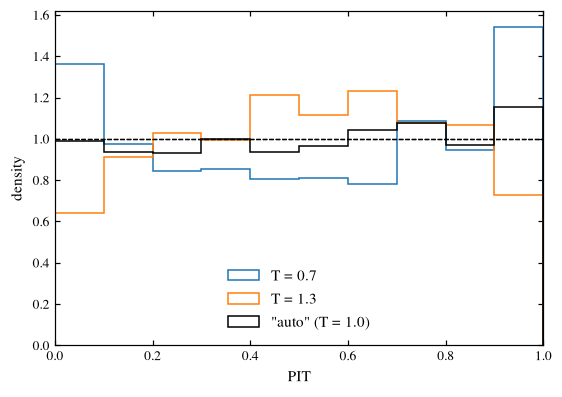

In [11]:
fig, ax = plt.subplots(figsize=(5, 3.5), layout="constrained")
for t, (_, pit) in zip(temperatures, runs, strict=True):
    if t in (0.7, 1.3):
        plotting.plot_pit(pit, ax=ax, n_bins=10, label=f"T = {t}")
plotting.plot_pit(
    pit_default, ax=ax, n_bins=10, label='"auto" (T = 1.0)', color="k"
)
ax.set_xlabel("PIT")
ax.set_ylabel("density")
ax.legend(loc="lower center")

The figure shows the PIT histograms of the default temperature and of the two
extremes, with the dashed line marking the flat histogram of calibrated
distributions. We see that the lowest temperature piles PIT values near 0 and
1, the signature of distributions that are too narrow, and the highest one
piles them in the middle, the signature of distributions that are too wide.
The coverage column of the table agrees, rising steadily with the temperature
from 58.6% at T = 0.7 to 73.8% at T = 1.3, while the default stays close to
68% (67.9%). The CRPS changes much less than the coverage, and the NLL is
best at the default.

## Outlier clipping

`outlier_threshold` soft-clips each feature at that many standard deviations
of the context. Values beyond the bound keep their order but lose their
leverage. Under `transforms="auto"`, `"auto"` is the model's own clip (12
standard deviations for TabPFN-3.5), and `None` turns clipping off. The
angles of `kin8nm` lie within $\pm\pi/2$, so no feature in the data is near a
bound. We therefore set the first angle of 200 test rows to 20 radians, more
than 20 standard deviations from its mean, and score only those rows with and
without the clip.

In [12]:
X_bad = X_test.iloc[:200].copy()
X_bad.iloc[:, 0] = 20.0
y_bad = y_test[:200]

by_outliers = show(
    [
        measure("clean rows", X_test.iloc[:200], y_bad)[0],
        measure("corrupted, auto clip", X_bad, y_bad)[0],
        measure("corrupted, no clip", X_bad, y_bad, outlier_threshold=None)[0],
        measure("corrupted, clip at 4", X_bad, y_bad, outlier_threshold=4.0)[0],
    ]
)
by_outliers

,crps,nll,coverage_68,time [s]
setting,,,,
clean rows,0.0374,-1.3193,0.695,0.8227
"corrupted, auto clip",0.1558,0.3403,0.400,0.7329
"corrupted, no clip",0.1573,0.2412,0.450,0.7230
"corrupted, clip at 4",0.1491,0.4126,0.380,0.7307


The table compares the same 200 rows scored clean and corrupted. A
corrupted angle carries no information about the arm, so the corrupted
rows score far worse than the clean ones with any setting. The clip changes
the scores only modestly, and no setting is best on every metric: the clip
at 4 standard deviations gives the lowest CRPS, while no clip gives the
lowest NLL and the best coverage. Since the clean angles lie far inside
every bound, we expect the clip to change little on clean data like that
of `kin8nm`.

## Precision and device

`mixed_precision=True` (the default) runs each model's reduced-precision
path on a GPU (float16 autocast for TabPFN, bfloat16 for TabFM), which
saves memory and time, while a CPU always runs in float32. `device="auto"`
picks the first CUDA GPU when there is one and the CPU otherwise, and
`"cuda:1"` or `"cpu"` choose one explicitly.

## TabFM's own settings

TabFM builds a density from in-context classifiers over equal-mass bins of
the target: `n_coarse_bins` classes at the first level and `n_fine_bins`
within each, so that the default 10 by 10 gives 100 bins, which set the
resolution of the histogram. `n_dither` repeats the whole hierarchy with
its bin edges shifted by a fraction of a bin and mixes the copies, which
smooths the steps of the histogram at a proportional cost. `prior_shift="em"`
corrects for label shift, the case in which the targets of the context are
distributed unlike those of the queries while the features at a given
target, $p(x \mid y)$, are unchanged, as for a biased spectroscopic sample.
Since TabFM runs eleven classifiers per hierarchy, it is much slower than
TabPFN, so we give it only the first 1,000 context rows and 4 members, and
score 300 test rows.

In [13]:
if importlib.util.find_spec("tabfm") is None:
    print("TabFM is not installed; skipping this section.")
else:
    by_dither = show(
        [
            measure(
                f"TabFM, n_dither={n}",
                X_test.iloc[:300],
                y_test[:300],
                n_context=1_000,
                backend="tabfm",
                n_estimators=4,
                n_dither=n,
            )[0]
            for n in (1, 3)
        ]
    )
    display(by_dither)  # noqa: F821 - a notebook builtin.

Loading weights from local directory


,crps,nll,coverage_68,time [s]
setting,,,,
"TabFM, n_dither=1",0.0429,-0.9150,0.7200,13.5341
"TabFM, n_dither=3",0.0423,-1.0115,0.7333,28.7671


The table shows that three dithers improve the CRPS slightly and the NLL
more clearly, since the mixture of shifted histograms is smoother, and that
they take a little over twice as long as one (the loading of the model does
not repeat). With only 1,000 context rows and 4 members, these scores are
not comparable with those of TabPFN above.

## Next steps

Every setting above is a constructor parameter of `LazyModel`, so
`GridSearchCV` can search over any of them with no prefix, as the
[Choosing a model](https://lazy-tfm.readthedocs.io/en/latest/tutorials/choosing_a_model.html)
tutorial does. For the full list of
shared parameters and how each model implements them, see
[One interface for every model](https://lazy-tfm.readthedocs.io/en/latest/guide/interface.html),
and for how the seed and the recipe are recorded, see
[Reproducibility and provenance](https://lazy-tfm.readthedocs.io/en/latest/guide/reproducibility.html).